# Linear Regression with scikit-learn: A Hands-On Tutorial (Biological Data)

This notebook is a practical, from-scratch walkthrough of **simple** and
**multiple linear regression** using `scikit-learn`, applied to a
**biological / clinical dataset**. Along the way we cover the questions
every regression analysis needs to answer:

1. How do I fit a simple linear regression (one predictor)?
2. How do I fit a multiple linear regression (several predictors)?
3. How do I judge whether a model is doing well — on the data it was
   trained on **and** on unseen (test) data?
4. What is **multicollinearity**, why is it a problem, and how do I detect
   and fix it (correlation matrices, VIF, bootstrapped coefficient
   stability, Ridge regression)?
5. What are the **assumptions of linear regression**, and how do I check
   each one with diagnostic plots and statistical tests?

**About the dataset.** We simulate a cohort of patients and predict
**systolic blood pressure (SBP, mmHg)** from age, BMI, resting heart rate,
total cholesterol, and weekly physical activity — a classic style of
question in cardiovascular epidemiology (think: a simplified,
teaching-sized cousin of a Framingham Heart Study-type analysis).

The data is **simulated, not real patient data** — this notebook runs in a
sandboxed environment with no live internet access, so a real dataset can't
be reliably downloaded here (and the small biological datasets that ship
locally with scikit-learn, like `load_linnerud`, only have 20 rows — too
few to demonstrate train/test splitting, bootstrapping, or multicollinearity
convincingly). Simulating the data has a real teaching advantage, too:
because *we* choose the true relationship, we can check whatever the model
estimates against ground truth — something you never get with real data.
If you want to redo this analysis on a real dataset, swap the
`generate_clinical_data()` function in Section 2 for a `pd.read_csv(...)`
of your own cohort (e.g. NHANES, MIMIC-IV, or a UCI Machine Learning
Repository health dataset) — everything downstream works unchanged.

> **Outline**
> 1. Setup
> 2. Simulate a clinical dataset
> 3. Exploratory data analysis
> 4. Train / test split
> 5. Simple linear regression
> 6. Multiple linear regression (and a train-vs-test overfitting demo)
> 7. Multicollinearity: detection and remedies
> 8. Checking the assumptions of linear regression
> 9. Assumption summary table
> 10. Key takeaways & exercises

## 1. Setup

We'll use `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for
plotting, `scikit-learn` for modeling, and a few functions from `scipy.stats`
for the statistical tests used in the assumption checks later on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

from scipy import stats
from scipy.stats import chi2

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 100)

RANDOM_STATE = 42       # controls the simulated data
SPLIT_RANDOM_STATE = 9  # controls the train/test split
np.random.seed(RANDOM_STATE)

## 2. Simulate a Clinical Dataset

We simulate a cohort of patients with five variables measured per person,
four of which have a **true, known effect** on systolic blood pressure:

| Feature | Meaning | True effect on SBP |
|---|---|---|
| `age_years` | patient age | + (older -> higher blood pressure) |
| `bmi` | body mass index (kg/m²) | + (higher BMI -> higher blood pressure) |
| `resting_heart_rate_bpm` | resting heart rate | + (higher resting HR -> higher blood pressure) |
| `cholesterol_mgdl` | total cholesterol (mg/dL) | weak + (small, noisy effect) |
| `physical_activity_hrs_per_week` | hours of exercise/week | − (more activity -> lower blood pressure, protective) |

The generating process is:

```
SBP = 60 + 0.5·age_years + 0.8·bmi + 0.15·resting_heart_rate_bpm
        + 0.05·cholesterol_mgdl − 1.2·physical_activity_hrs_per_week + noise
```

We also bake in one realistic, *mild* natural correlation — resting heart
rate tends to run a little higher in patients with higher BMI — since real
biological variables are rarely perfectly independent. Because we control
the data-generating process, we can later compare the regression's
*estimated* coefficients against these *true* coefficients — something you
almost never get to do with real clinical data.

In [2]:
TRUE_INTERCEPT = 60.0
TRUE_COEFS = {
    "age_years": 0.5,
    "bmi": 0.8,
    "resting_heart_rate_bpm": 0.15,
    "cholesterol_mgdl": 0.05,
    "physical_activity_hrs_per_week": -1.2,
}

def generate_clinical_data(n=500, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)

    age_years = rng.normal(45, 15, n).clip(18, 85)
    bmi = rng.normal(26, 4, n).clip(16, 45)
    # resting heart rate is mildly, naturally correlated with BMI
    resting_heart_rate_bpm = (70 + 0.4 * (bmi - 26) + rng.normal(0, 8, n)).clip(45, 115)
    cholesterol_mgdl = rng.normal(200, 35, n).clip(100, 350)
    physical_activity_hrs_per_week = rng.exponential(3, n).clip(0, 16)

    noise = rng.normal(0, 8, n)
    sbp = (
        TRUE_INTERCEPT
        + TRUE_COEFS["age_years"] * age_years
        + TRUE_COEFS["bmi"] * bmi
        + TRUE_COEFS["resting_heart_rate_bpm"] * resting_heart_rate_bpm
        + TRUE_COEFS["cholesterol_mgdl"] * cholesterol_mgdl
        + TRUE_COEFS["physical_activity_hrs_per_week"] * physical_activity_hrs_per_week
        + noise
    ).clip(85, 210)

    return pd.DataFrame({
        "age_years": age_years.round(1),
        "bmi": bmi.round(1),
        "resting_heart_rate_bpm": resting_heart_rate_bpm.round(1),
        "cholesterol_mgdl": cholesterol_mgdl.round(1),
        "physical_activity_hrs_per_week": physical_activity_hrs_per_week.round(2),
        "systolic_bp": sbp.round(1),
    })

df = generate_clinical_data()
df.head()

,age_years,bmi,resting_heart_rate_bpm,cholesterol_mgdl,physical_activity_hrs_per_week,systolic_bp
0,49.6,31.5,71.7,180.2,0.09,132.5
1,29.4,29.6,65.6,178.1,0.93,123.2
2,56.3,23.1,65.5,246.4,1.72,124.3
3,59.1,20.0,72.7,211.6,1.33,120.6
4,18.0,16.0,66.0,192.6,1.59,113.1


In [3]:
df.describe().round(2)

,age_years,bmi,resting_heart_rate_bpm,cholesterol_mgdl,physical_activity_hrs_per_week,systolic_bp
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,44.93,25.84,69.91,194.46,2.98,120.23
std,14.07,4.02,8.27,35.05,2.99,11.48
min,18.00,16.00,46.20,100.00,0.02,85.00
25%,34.98,23.08,64.57,172.35,0.78,113.25
50%,45.05,26.00,70.05,195.25,1.98,120.30
75%,53.82,28.42,75.30,217.80,4.06,128.20
max,85.00,38.70,94.60,302.00,16.00,158.30


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age_years                       500 non-null    float64
 1   bmi                             500 non-null    float64
 2   resting_heart_rate_bpm          500 non-null    float64
 3   cholesterol_mgdl                500 non-null    float64
 4   physical_activity_hrs_per_week  500 non-null    float64
 5   systolic_bp                     500 non-null    float64
dtypes: float64(6)
memory usage: 23.6 KB


## 3. Exploratory Data Analysis

Before modeling, let's look at the distributions and pairwise relationships.

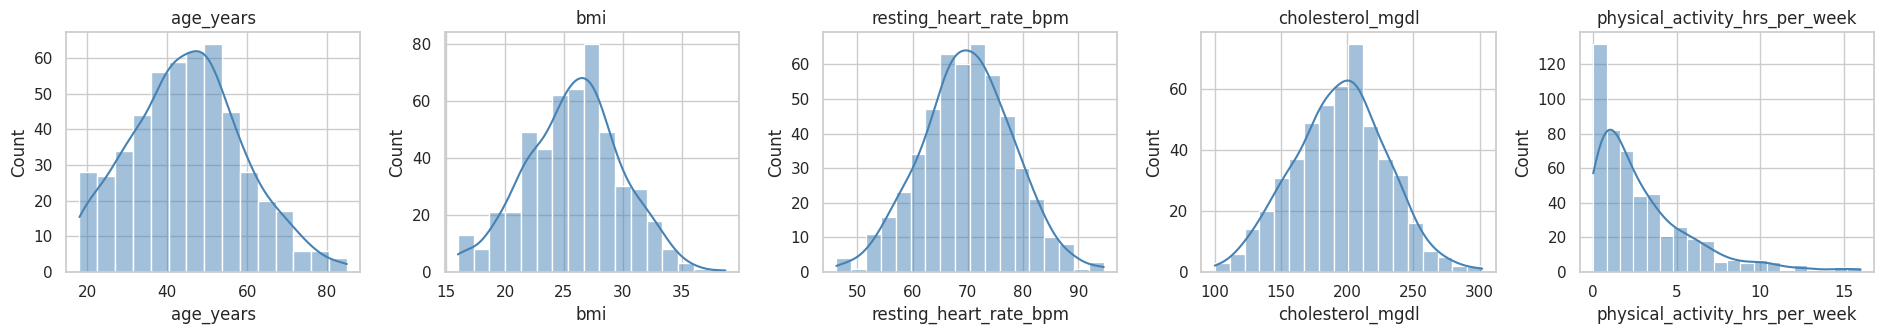

In [5]:
predictor_cols = ["age_years", "bmi", "resting_heart_rate_bpm",
                   "cholesterol_mgdl", "physical_activity_hrs_per_week"]

fig, axes = plt.subplots(1, 5, figsize=(19, 3.5))
for ax, col in zip(axes, predictor_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

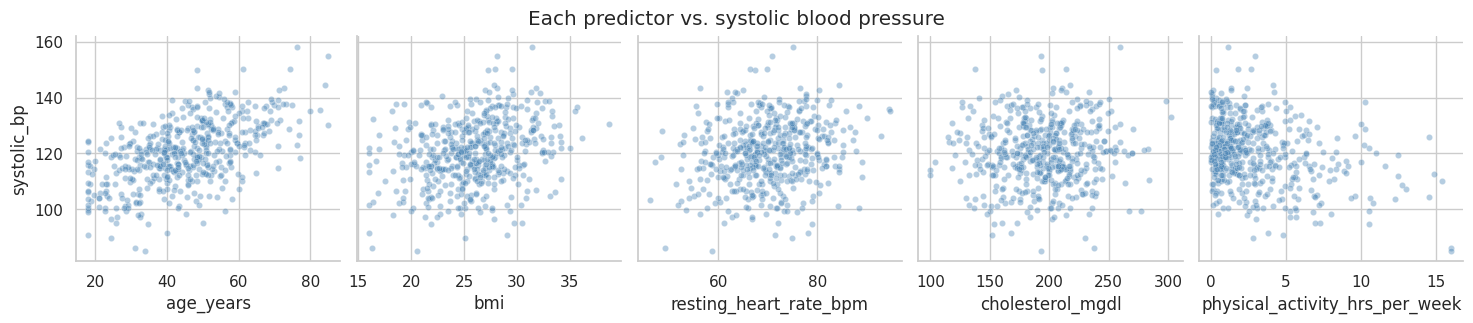

In [6]:
sns.pairplot(df, x_vars=predictor_cols, y_vars=["systolic_bp"], height=3, kind="scatter",
             plot_kws={"alpha": 0.4, "s": 20, "color": "steelblue"})
plt.suptitle("Each predictor vs. systolic blood pressure", y=1.05)
plt.show()

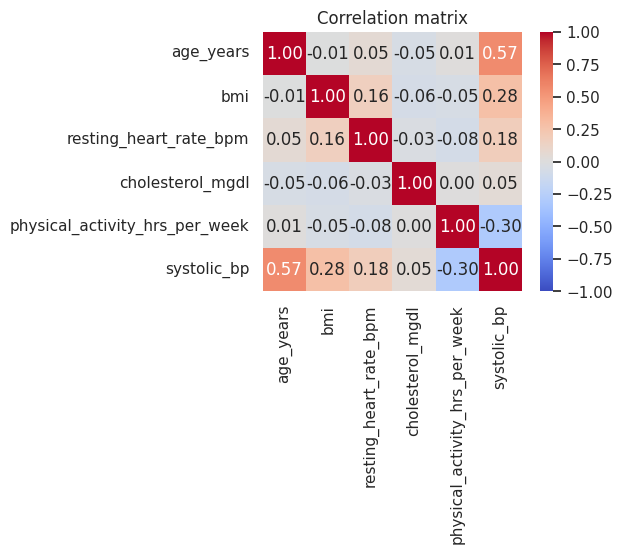

In [7]:
plt.figure(figsize=(6.5, 5.5))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

`age_years` is clearly the feature most strongly correlated with
`systolic_bp` — consistent with real epidemiology, where age is one of the
strongest single predictors of blood pressure. That makes it a natural
candidate for a **simple** linear regression before we bring in the other
predictors for a **multiple** linear regression. Notice also the mild
correlation between `bmi` and `resting_heart_rate_bpm` we built into the
simulation — real biological predictors are rarely perfectly independent,
which foreshadows the multicollinearity discussion in Section 7.

## 4. Train / Test Split

We hold out 20% of the patients as a **test set** that the model never sees
during fitting. This is what lets us honestly evaluate how well the model
*generalizes* to new patients, rather than just how well it memorizes the
training cohort.

In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SPLIT_RANDOM_STATE)
y_train = train_df["systolic_bp"]
y_test = test_df["systolic_bp"]

print(f"Training patients: {len(train_df)}")
print(f"Testing patients:  {len(test_df)}")

Training patients: 400
Testing patients:  100


## 5. Simple Linear Regression

Simple linear regression fits a single predictor:

$$ \hat{y} = b_0 + b_1 x $$

We'll predict `systolic_bp` from `age_years` alone.

In [9]:
X_train_simple = train_df[["age_years"]]
X_test_simple = test_df[["age_years"]]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

print(f"Intercept (b0):             {simple_model.intercept_:,.2f}")
print(f"Coefficient for age_years:  {simple_model.coef_[0]:,.3f}")
print(f"(true intercept / slope were {TRUE_INTERCEPT:,} and {TRUE_COEFS['age_years']}, "
      "but this model is missing 4 real predictors, so we don't expect a perfect match)")

Intercept (b0):             99.36
Coefficient for age_years:  0.459
(true intercept / slope were 60.0 and 0.5, but this model is missing 4 real predictors, so we don't expect a perfect match)


### Evaluating training vs. testing performance

We'll reuse this helper throughout the notebook: it reports **R²**
(fraction of variance explained), **RMSE** (root mean squared error, in
mmHg), and **MAE** (mean absolute error) on both the training and the test
split.

A model that fits training data far better than test data is a classic sign
of **overfitting**; a model that does poorly on both is likely
**underfitting**. We want train and test scores to be close together *and*
both reasonably good.

In [10]:
all_reports = []

def regression_report(model, X_train, y_train, X_test, y_test, name="Model"):
    rows = []
    for split_name, X, y in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        y_pred = model.predict(X)
        rows.append({
            "Model": name,
            "Split": split_name,
            "R2": r2_score(y, y_pred),
            "RMSE": root_mean_squared_error(y, y_pred),
            "MAE": mean_absolute_error(y, y_pred),
        })
    report = pd.DataFrame(rows)
    all_reports.append(report)
    return report

report_simple = regression_report(simple_model, X_train_simple, y_train,
                                   X_test_simple, y_test, "Simple (age_years)")
report_simple.round(3)

,Model,Split,R2,RMSE,MAE
0,Simple (age_years),Train,0.319,9.634,7.754
1,Simple (age_years),Test,0.319,8.747,6.720


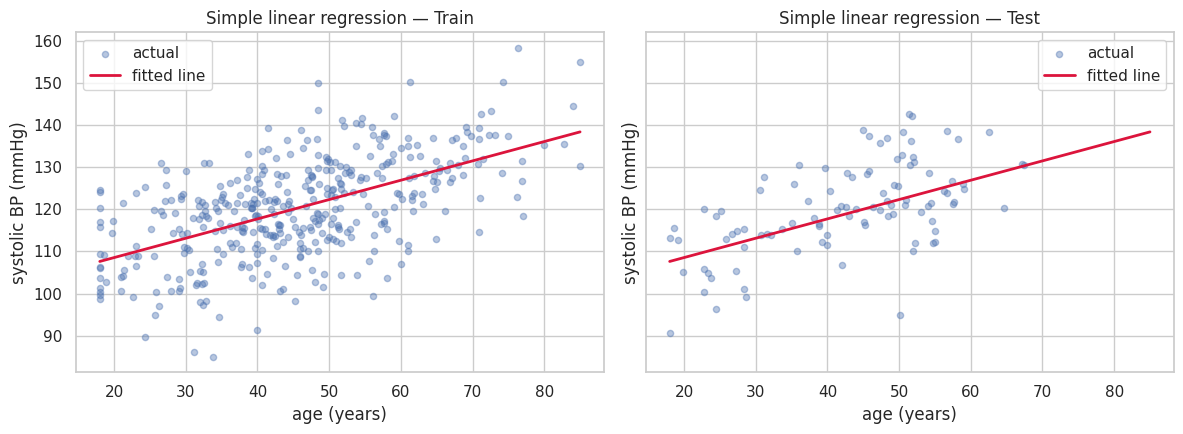

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x_line = np.linspace(df["age_years"].min(), df["age_years"].max(), 100).reshape(-1, 1)
y_line = simple_model.predict(pd.DataFrame(x_line, columns=["age_years"]))

for ax, (name, X, y) in zip(axes, [("Train", X_train_simple, y_train), ("Test", X_test_simple, y_test)]):
    ax.scatter(X["age_years"], y, alpha=0.4, s=20, label="actual")
    ax.plot(x_line, y_line, color="crimson", linewidth=2, label="fitted line")
    ax.set_title(f"Simple linear regression — {name}")
    ax.set_xlabel("age (years)")
    ax.set_ylabel("systolic BP (mmHg)")
    ax.legend()
plt.tight_layout()
plt.show()

The R² on train and test are close to each other, so the simple model
generalizes about as well as it fits — it's just missing information,
since `bmi`, `resting_heart_rate_bpm`, `cholesterol_mgdl`, and
`physical_activity_hrs_per_week` also drive blood pressure. That motivates
moving to multiple linear regression.

## 6. Multiple Linear Regression

Multiple linear regression extends the model to several predictors:

$$ \hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \dots + b_k x_k $$

We now use all five real predictors: `age_years`, `bmi`,
`resting_heart_rate_bpm`, `cholesterol_mgdl`, and
`physical_activity_hrs_per_week`.

In [12]:
features = ["age_years", "bmi", "resting_heart_rate_bpm",
            "cholesterol_mgdl", "physical_activity_hrs_per_week"]
X_train_multi = train_df[features]
X_test_multi = test_df[features]

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train)

coef_compare = pd.DataFrame({
    "Feature": features,
    "True coefficient": [TRUE_COEFS[f] for f in features],
    "Estimated coefficient": multi_model.coef_,
})
coef_compare["Difference"] = coef_compare["Estimated coefficient"] - coef_compare["True coefficient"]
print(f"Intercept: estimated {multi_model.intercept_:,.2f}  (true {TRUE_INTERCEPT:,})")
coef_compare.round(3)

Intercept: estimated 67.24  (true 60.0)


,Feature,True coefficient,Estimated coefficient,Difference
0,age_years,0.50,0.462,-0.038
1,bmi,0.80,0.882,0.082
2,resting_heart_rate_bpm,0.15,0.104,-0.046
3,cholesterol_mgdl,0.05,0.026,-0.024
4,physical_activity_hrs_per_week,-1.20,-1.083,0.117


With all five real predictors included and no redundant/collinear
features, the estimated coefficients land close to the true values — this
is what a well-specified linear model looks like. (`cholesterol_mgdl`'s
estimate is noisier than the others — its true effect is small relative to
the noise level, exactly as in real studies where cholesterol's link to
blood pressure is comparatively weak.)

In [13]:
report_multi = regression_report(multi_model, X_train_multi, y_train,
                                  X_test_multi, y_test, "Multiple (5 features)")
pd.concat([report_simple, report_multi], ignore_index=True).round(3)

,Model,Split,R2,RMSE,MAE
0,Simple (age_years),Train,0.319,9.634,7.754
1,Simple (age_years),Test,0.319,8.747,6.720
2,Multiple (5 features),Train,0.514,8.139,6.572
3,Multiple (5 features),Test,0.432,7.990,6.447


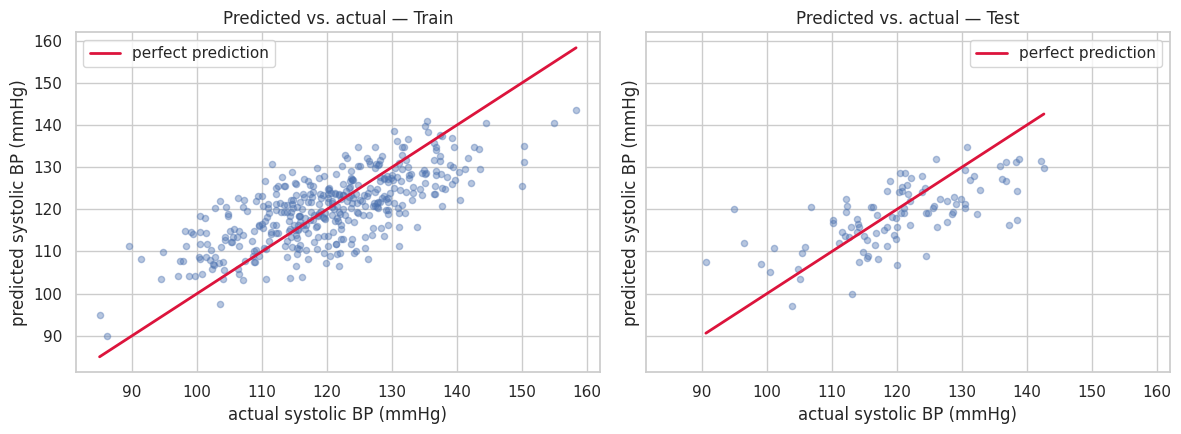

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
for ax, (name, X, y) in zip(axes, [("Train", X_train_multi, y_train), ("Test", X_test_multi, y_test)]):
    y_pred = multi_model.predict(X)
    ax.scatter(y, y_pred, alpha=0.4, s=20)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, color="crimson", linewidth=2, label="perfect prediction")
    ax.set_title(f"Predicted vs. actual — {name}")
    ax.set_xlabel("actual systolic BP (mmHg)")
    ax.set_ylabel("predicted systolic BP (mmHg)")
    ax.legend()
plt.tight_layout()
plt.show()

Adding the extra, genuinely relevant predictors raised R² and lowered RMSE
on **both** train and test, and the two splits still track each other
closely — a sign the model generalizes rather than merely memorizes.

### 6.1 Why the train/test gap matters: a quick overfitting demo

To make the train-vs-test idea concrete, let's deliberately break it. We add
15 columns of **pure random noise** (no relationship to blood pressure
whatsoever — imagine 15 meaningless lab values thrown into the model) and
refit. A linear model has enough flexibility to "explain" a little bit of
the training noise by chance, which can nudge training R² up — while it
does nothing for (or even hurts) test R², since the noise columns carry no
real signal to generalize.

In [15]:
rng = np.random.default_rng(7)
n_noise = 15
noise_cols = [f"noise_{i}" for i in range(n_noise)]

X_train_noisy = pd.concat([
    X_train_multi.reset_index(drop=True),
    pd.DataFrame(rng.normal(size=(len(X_train_multi), n_noise)), columns=noise_cols),
], axis=1)
X_test_noisy = pd.concat([
    X_test_multi.reset_index(drop=True),
    pd.DataFrame(rng.normal(size=(len(X_test_multi), n_noise)), columns=noise_cols),
], axis=1)
y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

noisy_model = LinearRegression().fit(X_train_noisy, y_train_reset)
report_noisy = regression_report(noisy_model, X_train_noisy, y_train_reset,
                                  X_test_noisy, y_test_reset, "Multiple + 15 noise features")

comparison = pd.concat(all_reports, ignore_index=True)
comparison.round(4)

,Model,Split,R2,RMSE,MAE
0,Simple (age_years),Train,0.3194,9.6337,7.7536
1,Simple (age_years),Test,0.3189,8.7471,6.7197
2,Multiple (5 features),Train,0.5142,8.1391,6.5716
3,Multiple (5 features),Test,0.4317,7.9901,6.4475
4,Multiple + 15 noise features,Train,0.5269,8.0323,6.5717
5,Multiple + 15 noise features,Test,0.4007,8.2052,6.5099


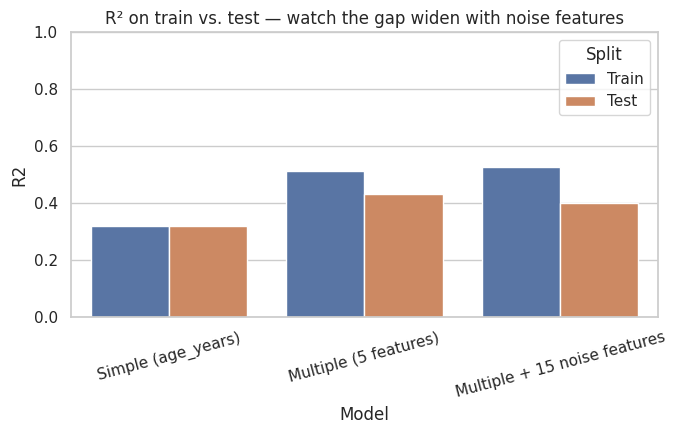

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=comparison, x="Model", y="R2", hue="Split", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("R² on train vs. test — watch the gap widen with noise features")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

Notice the pattern: adding noise features either leaves test R² roughly flat
or makes it worse, while training R² can creep up. **The gap between
training and test performance — not the training score alone — is the
signal to watch for overfitting.** This is exactly why we always evaluate
on a held-out test set instead of trusting training performance alone —
imagine accidentally including 15 spurious lab measurements in a real model
and believing it improved because training R² went up.

## 7. Multicollinearity

**Multicollinearity** occurs when two or more predictors are strongly
correlated with each other. It doesn't necessarily hurt a model's
*predictive accuracy*, but it can badly hurt:

- **Coefficient stability** — small changes in the data can swing the
  estimated coefficients wildly.
- **Interpretability** — coefficients can take implausible signs or
  magnitudes because the model can't tell which correlated variable
  deserves the "credit".

This happens constantly in real biological/clinical datasets. A very common
real-world cause: **the same lab value reported in two different units**.
Total cholesterol is reported in mg/dL in the US and in mmol/L in most other
countries; if a merged international dataset accidentally keeps *both*
columns, you've created a near-perfect duplicate. Let's simulate exactly
that: `cholesterol_mmol_L`, the same cholesterol measurement converted to
mmol/L (1 mg/dL x 0.02586 = 1 mmol/L), plus a touch of measurement/rounding
noise.

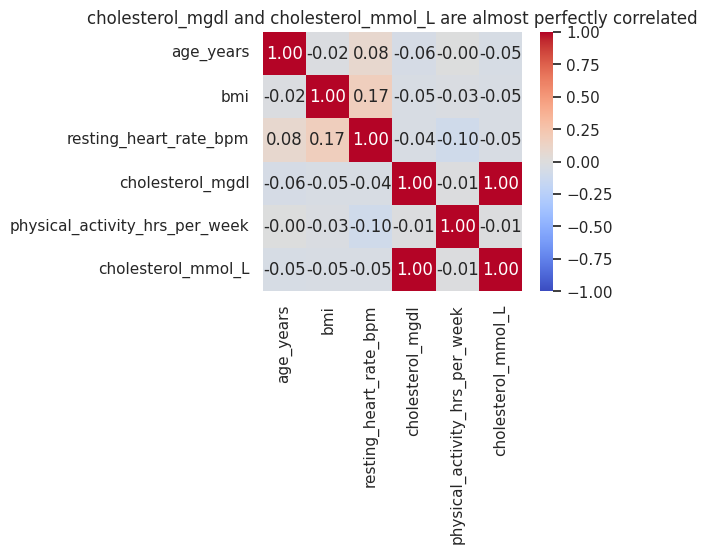

In [17]:
mc_rng = np.random.default_rng(123)
train_df = train_df.copy()
test_df = test_df.copy()
train_df["cholesterol_mmol_L"] = train_df["cholesterol_mgdl"] * 0.02586 + mc_rng.normal(0, 0.05, len(train_df))
test_df["cholesterol_mmol_L"] = test_df["cholesterol_mgdl"] * 0.02586 + mc_rng.normal(0, 0.05, len(test_df))

features_collinear = features + ["cholesterol_mmol_L"]
X_train_collinear = train_df[features_collinear]
X_test_collinear = test_df[features_collinear]

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(X_train_collinear.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("cholesterol_mgdl and cholesterol_mmol_L are almost perfectly correlated")
plt.tight_layout()
plt.show()

In [18]:
collinear_model = LinearRegression().fit(X_train_collinear, y_train)

coef_side_by_side = pd.DataFrame({
    "Feature": features_collinear,
    "Coefficient WITHOUT cholesterol_mmol_L": list(multi_model.coef_) + [np.nan],
    "Coefficient WITH cholesterol_mmol_L": collinear_model.coef_,
})
coef_side_by_side.round(3)

,Feature,Coefficient WITHOUT cholesterol_mmol_L,Coefficient WITH cholesterol_mmol_L
0,age_years,0.462,0.463
1,bmi,0.882,0.883
2,resting_heart_rate_bpm,0.104,0.103
3,cholesterol_mgdl,0.026,0.136
4,physical_activity_hrs_per_week,-1.083,-1.082
5,cholesterol_mmol_L,NaN,-4.246


Even though `cholesterol_mgdl` and `cholesterol_mmol_L` measure exactly the
same underlying quantity, the model has to arbitrarily split "credit" for
the cholesterol effect between them — the individual coefficients can look
very different (even flip sign) from the clean, non-redundant model, even
though both features together are just standing in for one real quantity:
total cholesterol.

### 7.1 Proving the instability: bootstrap resampling

A cleaner way to *see* instability than eyeballing one fit: refit the model
on many bootstrap resamples of the training data and look at how much the
`cholesterol_mgdl` coefficient bounces around.

In [19]:
def bootstrap_coefs(X, y, make_model, n_boot=200, seed=0):
    rng = np.random.default_rng(seed)
    n = len(X)
    rows = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        Xb, yb = X.iloc[idx], y.iloc[idx]
        m = make_model().fit(Xb, yb)
        rows.append(dict(zip(X.columns, m.coef_)))
    return pd.DataFrame(rows)

boot_clean = bootstrap_coefs(X_train_multi, y_train, LinearRegression)
boot_collinear = bootstrap_coefs(X_train_collinear, y_train, LinearRegression)

print("Std. dev. of the bootstrapped cholesterol_mgdl coefficient")
print(f"  WITHOUT cholesterol_mmol_L (clean model):  {boot_clean['cholesterol_mgdl'].std():.4f}")
print(f"  WITH cholesterol_mmol_L (collinear model): {boot_collinear['cholesterol_mgdl'].std():.4f}")

Std. dev. of the bootstrapped cholesterol_mgdl coefficient
  WITHOUT cholesterol_mmol_L (clean model):  0.0125
  WITH cholesterol_mmol_L (collinear model): 0.2184


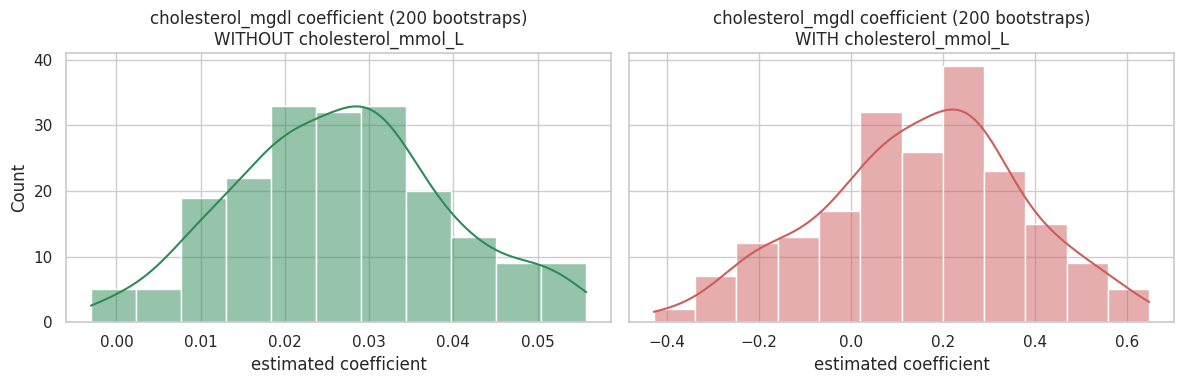

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.histplot(boot_clean["cholesterol_mgdl"], ax=axes[0], color="seagreen", kde=True)
axes[0].set_title("cholesterol_mgdl coefficient (200 bootstraps)\nWITHOUT cholesterol_mmol_L")
sns.histplot(boot_collinear["cholesterol_mgdl"], ax=axes[1], color="indianred", kde=True)
axes[1].set_title("cholesterol_mgdl coefficient (200 bootstraps)\nWITH cholesterol_mmol_L")
for ax in axes:
    ax.set_xlabel("estimated coefficient")
plt.tight_layout()
plt.show()

The spread of plausible `cholesterol_mgdl` coefficients is dramatically
wider once the redundant `cholesterol_mmol_L` feature is present — the
textbook signature of multicollinearity.

### 7.2 Detecting it formally: Variance Inflation Factor (VIF)

The **Variance Inflation Factor** for predictor $x_i$ is computed by
regressing $x_i$ on *all the other predictors* and using that regression's
R²:

$$ VIF_i = \frac{1}{1 - R^2_i} $$

A common rule of thumb: VIF > 5 (some use 10) signals problematic
multicollinearity for that predictor. We don't have `statsmodels` available
in this environment, so we compute VIF directly with `LinearRegression`.

In [21]:
def compute_vif(X):
    rows = []
    for col in X.columns:
        other_cols = [c for c in X.columns if c != col]
        r2 = LinearRegression().fit(X[other_cols], X[col]).score(X[other_cols], X[col])
        vif = np.inf if r2 >= 1 else 1 / (1 - r2)
        rows.append({"Feature": col, "VIF": vif})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_collinear = compute_vif(X_train_collinear)
vif_collinear.round(2)

,Feature,VIF
0,cholesterol_mgdl,314.78
1,cholesterol_mmol_L,314.58
2,resting_heart_rate_bpm,1.05
3,bmi,1.03
4,age_years,1.02
5,physical_activity_hrs_per_week,1.01


`cholesterol_mgdl` and `cholesterol_mmol_L` both show very high VIF values,
while `age_years`, `bmi`, `resting_heart_rate_bpm`, and
`physical_activity_hrs_per_week` stay low — VIF correctly flags exactly the
two variables that are redundant with each other. (`bmi` and
`resting_heart_rate_bpm` show a small VIF bump above 1 too, reflecting the
mild, realistic correlation we built into the simulation — nowhere near the
severity of the two cholesterol columns.)

### 7.3 Remedies

Three common ways to deal with multicollinearity:

1. **Drop one of the redundant variables** (simplest, most interpretable —
   here, just keep cholesterol in one unit).
2. **Combine them** (e.g., standardize onto one unit before merging
   datasets in the first place).
3. **Use a regularized model** (Ridge regression) that shrinks and
   stabilizes coefficients instead of letting OLS split credit arbitrarily.

**Remedy 1 — drop the redundant feature.** We already have this: it's our
original `multi_model` / `X_train_multi`. Let's re-run VIF on it to confirm
the problem is gone.

In [22]:
vif_clean = compute_vif(X_train_multi)
vif_clean.round(2)

,Feature,VIF
0,resting_heart_rate_bpm,1.05
1,bmi,1.03
2,age_years,1.01
3,physical_activity_hrs_per_week,1.01
4,cholesterol_mgdl,1.01


All VIF values are now comfortably below the rule-of-thumb threshold of 5.

**Remedy 3 — Ridge regression**, for comparison, without dropping anything:

In [23]:
boot_ridge_collinear = bootstrap_coefs(X_train_collinear, y_train, lambda: Ridge(alpha=300.0))

print("Std. dev. of the bootstrapped cholesterol_mgdl coefficient, WITH cholesterol_mmol_L present")
print(f"  Plain LinearRegression (OLS): {boot_collinear['cholesterol_mgdl'].std():.4f}")
print(f"  Ridge(alpha=300):             {boot_ridge_collinear['cholesterol_mgdl'].std():.4f}")

Std. dev. of the bootstrapped cholesterol_mgdl coefficient, WITH cholesterol_mmol_L present
  Plain LinearRegression (OLS): 0.2184
  Ridge(alpha=300):             0.0125


Ridge's L2 penalty shrinks and stabilizes the coefficients considerably —
useful when you want to *keep* correlated predictors in the model (e.g. for
prediction) rather than dropping one. It comes at the cost of biased,
harder-to-interpret individual coefficients, so for **interpretation** the
"drop or combine" approach from Remedy 1 is usually preferred; for pure
**prediction accuracy**, Ridge/Lasso are common choices.

From here on, we'll use the clean, non-redundant `multi_model` /
`X_train_multi` (5 real features, no collinearity) as our "final" model for
the assumption checks below.

## 8. Checking the Assumptions of Linear Regression

Ordinary least squares linear regression relies on a handful of
assumptions for its estimates and inference to be trustworthy:

1. **Linearity** — the relationship between predictors and the target is
   (approximately) linear.
2. **Independence of errors** — residuals aren't correlated with each
   other (important for time-ordered / clustered data, e.g. repeated
   measurements on the same patient).
3. **Homoscedasticity** — residuals have constant variance across the
   range of fitted values (no "fanning out").
4. **Normality of residuals** — residuals are approximately normally
   distributed (mainly matters for the validity of confidence intervals
   and hypothesis tests, less so for point predictions).
5. **No (or little) multicollinearity** among predictors — covered above.

We'll check assumptions 1–4 with diagnostic plots and tests on our final,
clean multiple regression model, using the **training residuals**.

In [24]:
fitted_train = multi_model.predict(X_train_multi)
residuals_train = y_train.values - fitted_train

print(f"Residuals: mean = {residuals_train.mean():.3f}, std = {residuals_train.std():.3f} mmHg")

Residuals: mean = -0.000, std = 8.139 mmHg


### 8.1 Linearity

If the model correctly captures the relationship, residuals plotted against
fitted values should show **no systematic pattern** — just a random cloud
scattered around zero. A curve or funnel shape suggests a missing
nonlinear term (e.g., a squared term, an interaction, or a transformation).

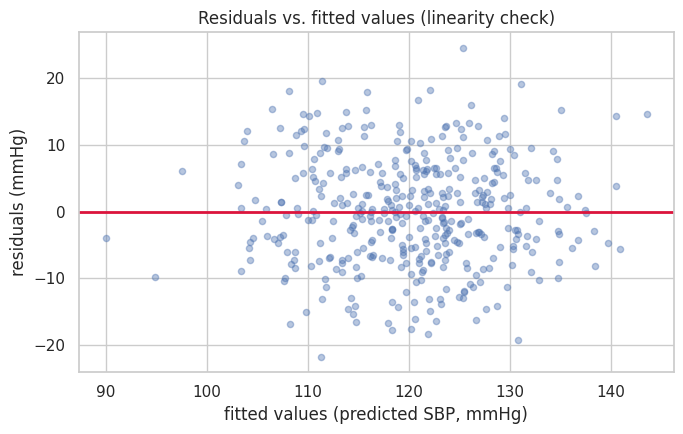

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(fitted_train, residuals_train, alpha=0.4, s=20)
ax.axhline(0, color="crimson", linewidth=2)
ax.set_xlabel("fitted values (predicted SBP, mmHg)")
ax.set_ylabel("residuals (mmHg)")
ax.set_title("Residuals vs. fitted values (linearity check)")
plt.tight_layout()
plt.show()

### 8.2 Independence of Errors

This assumption matters most for time-series or otherwise ordered/clustered
data — for example, several blood pressure readings taken over time from
the *same* patient would violate it. Our rows are one independent
measurement per patient, so we'd expect no such pattern, but here's how
you'd check it: the **Durbin–Watson statistic**,

$$ DW = \frac{\sum_{t=2}^{n}(e_t - e_{t-1})^2}{\sum_{t=1}^{n} e_t^2} $$

ranges from 0 to 4; values near **2** indicate no autocorrelation, values
toward 0 indicate positive autocorrelation, and values toward 4 indicate
negative autocorrelation.

Durbin-Watson statistic: 2.084  (≈2 means no autocorrelation)


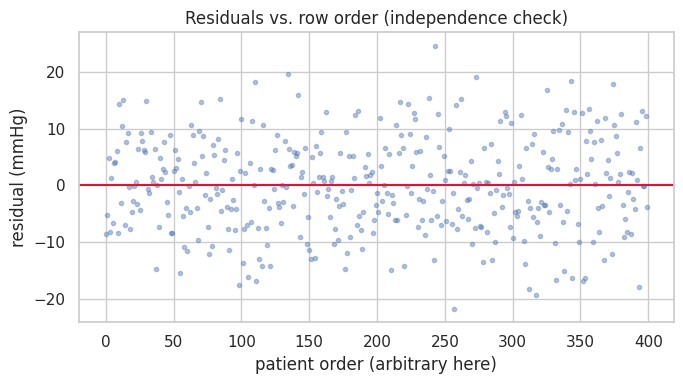

In [26]:
def durbin_watson(residuals):
    residuals = np.asarray(residuals)
    diff = np.diff(residuals)
    return np.sum(diff ** 2) / np.sum(residuals ** 2)

dw_stat = durbin_watson(residuals_train)
print(f"Durbin-Watson statistic: {dw_stat:.3f}  (≈2 means no autocorrelation)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(len(residuals_train)), residuals_train, marker="o", linestyle="", alpha=0.4, markersize=3)
ax.axhline(0, color="crimson", linewidth=1.5)
ax.set_xlabel("patient order (arbitrary here)")
ax.set_ylabel("residual (mmHg)")
ax.set_title("Residuals vs. row order (independence check)")
plt.tight_layout()
plt.show()

### 8.3 Homoscedasticity

Residual variance should stay roughly constant across the range of fitted
values. A "fanning out" or "fanning in" shape means variance changes with
the predicted value (heteroscedasticity), which biases standard errors
(and thus confidence intervals / p-values), even though it doesn't bias the
coefficients themselves.

We'll look at a **scale-location plot** (√|standardized residual| vs.
fitted value — should be flat) and run a **Breusch–Pagan test**: regress
the *squared* residuals on the predictors; if they explain a significant
share of the squared-residual variance, that's evidence of
heteroscedasticity.

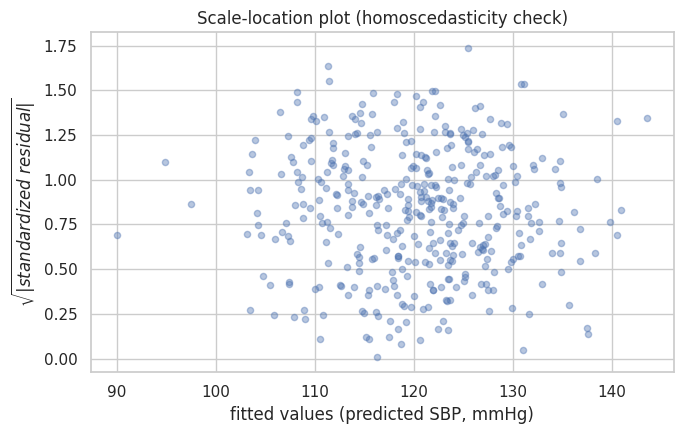

In [27]:
standardized_resid = residuals_train / residuals_train.std()
scale_location = np.sqrt(np.abs(standardized_resid))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(fitted_train, scale_location, alpha=0.4, s=20)
ax.set_xlabel("fitted values (predicted SBP, mmHg)")
ax.set_ylabel(r"$\sqrt{|standardized\ residual|}$")
ax.set_title("Scale-location plot (homoscedasticity check)")
plt.tight_layout()
plt.show()

In [28]:
def breusch_pagan_test(residuals, X):
    resid_sq = residuals ** 2
    aux_model = LinearRegression().fit(X, resid_sq)
    r2_aux = aux_model.score(X, resid_sq)
    n = len(X)
    lm_stat = n * r2_aux
    dof = X.shape[1]
    p_value = 1 - chi2.cdf(lm_stat, dof)
    return lm_stat, p_value

bp_stat, bp_pvalue = breusch_pagan_test(residuals_train, X_train_multi)
print(f"Breusch-Pagan LM statistic: {bp_stat:.3f}")
print(f"p-value: {bp_pvalue:.4f}")
print("-> " + ("Evidence of heteroscedasticity (p < 0.05)." if bp_pvalue < 0.05
                else "No strong evidence against homoscedasticity (p >= 0.05)."))

Breusch-Pagan LM statistic: 1.440
p-value: 0.9199
-> No strong evidence against homoscedasticity (p >= 0.05).


### 8.4 Normality of Residuals

We check this with a histogram, a **Q-Q plot** (quantiles of the residuals
against theoretical normal quantiles — points should hug the diagonal), and
the **Shapiro–Wilk test** (null hypothesis: the data is normally
distributed).

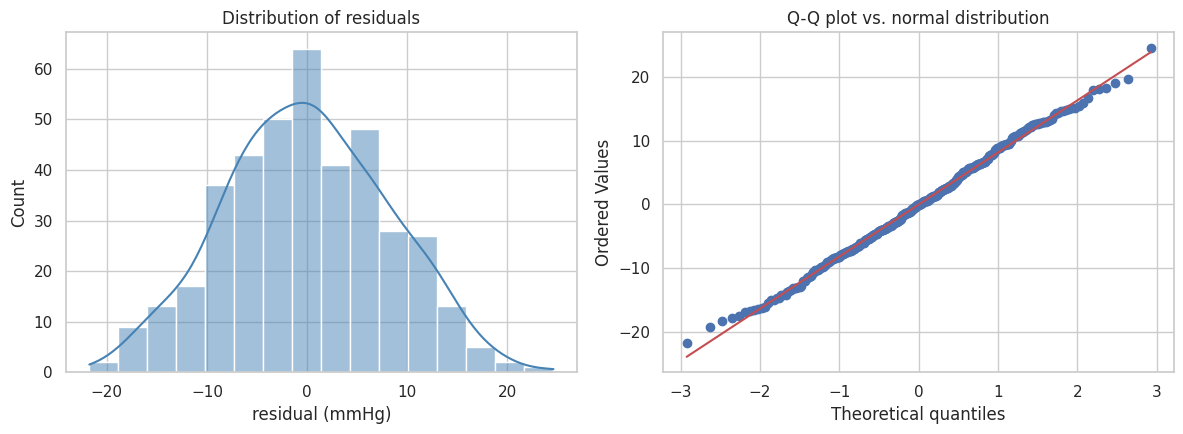

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(residuals_train, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of residuals")
axes[0].set_xlabel("residual (mmHg)")

stats.probplot(residuals_train, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs. normal distribution")

plt.tight_layout()
plt.show()

In [30]:
shapiro_stat, shapiro_pvalue = stats.shapiro(residuals_train)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_pvalue:.4f}")
print("-> " + ("Residuals depart from normality (p < 0.05)." if shapiro_pvalue < 0.05
                else "No strong evidence against normality (p >= 0.05)."))

Shapiro-Wilk statistic: 0.9968
p-value: 0.6192
-> No strong evidence against normality (p >= 0.05).


### 8.5 No Multicollinearity

We already covered this in depth in Section 7. For the final model
(`X_train_multi`, i.e. `age_years`, `bmi`, `resting_heart_rate_bpm`,
`cholesterol_mgdl`, `physical_activity_hrs_per_week` — no redundant
`cholesterol_mmol_L`), the VIF values were:

In [31]:
vif_clean.round(2)

,Feature,VIF
0,resting_heart_rate_bpm,1.05
1,bmi,1.03
2,age_years,1.01
3,physical_activity_hrs_per_week,1.01
4,cholesterol_mgdl,1.01


## 9. Assumption Summary

Pulling every diagnostic together into one checklist for the final model:

In [32]:
assumption_summary = pd.DataFrame([
    {
        "Assumption": "1. Linearity",
        "How we checked it": "Residuals vs. fitted values plot",
        "Result": "No strong curve/pattern visible",
        "Verdict": "Visual check — looks OK",
    },
    {
        "Assumption": "2. Independence of errors",
        "How we checked it": f"Durbin-Watson statistic = {dw_stat:.3f}",
        "Result": "Close to 2 -> little/no autocorrelation",
        "Verdict": "OK" if 1.5 <= dw_stat <= 2.5 else "Investigate",
    },
    {
        "Assumption": "3. Homoscedasticity",
        "How we checked it": f"Breusch-Pagan p-value = {bp_pvalue:.4f}",
        "Result": "Fail to reject constant variance" if bp_pvalue >= 0.05 else "Reject constant variance",
        "Verdict": "OK" if bp_pvalue >= 0.05 else "Investigate",
    },
    {
        "Assumption": "4. Normality of residuals",
        "How we checked it": f"Shapiro-Wilk p-value = {shapiro_pvalue:.4f}",
        "Result": "Fail to reject normality" if shapiro_pvalue >= 0.05 else "Reject normality",
        "Verdict": "OK" if shapiro_pvalue >= 0.05 else "Investigate",
    },
    {
        "Assumption": "5. No multicollinearity",
        "How we checked it": f"Max VIF (clean model) = {vif_clean['VIF'].max():.2f}",
        "Result": "All VIF well under 5",
        "Verdict": "OK" if vif_clean["VIF"].max() < 5 else "Investigate",
    },
])
assumption_summary

,Assumption,How we checked it,Result,Verdict
0,1. Linearity,Residuals vs. fitted values plot,No strong curve/pattern visible,Visual check — looks OK
1,2. Independence of errors,Durbin-Watson statistic = 2.084,Close to 2 -> little/no autocorrelation,OK
2,3. Homoscedasticity,Breusch-Pagan p-value = 0.9199,Fail to reject constant variance,OK
3,4. Normality of residuals,Shapiro-Wilk p-value = 0.6192,Fail to reject normality,OK
4,5. No multicollinearity,Max VIF (clean model) = 1.05,All VIF well under 5,OK


## 10. Key Takeaways & Exercises

**Takeaways**

- Simple linear regression (one predictor) is a special case of multiple
  linear regression (several predictors); both are fit in `scikit-learn`
  with the same `LinearRegression` API.
- Always evaluate on a **held-out test set**, not just training data — the
  *gap* between train and test performance (R², RMSE, MAE) tells you
  whether the model is overfitting, underfitting, or generalizing well.
  In a clinical setting this is the difference between a model that only
  looks good on the patients it was built from and one that will actually
  work on the next patient walking in the door.
- **Multicollinearity** among predictors doesn't necessarily hurt
  predictive accuracy, but it destabilizes and can make individual
  coefficients uninterpretable — a common real cause is the same
  measurement recorded twice (different units, different lab methods,
  merged datasets). Detect it with correlation matrices and **VIF**; fix
  it by dropping/combining redundant predictors or by using regularization
  (Ridge/Lasso).
- Linear regression rests on assumptions — **linearity, independence,
  homoscedasticity, normality of residuals, and no multicollinearity** —
  that are worth checking with residual plots and tests (Durbin-Watson,
  Breusch-Pagan, Shapiro-Wilk) rather than assumed blindly.

**Suggested exercises**

1. Try predicting `np.log(systolic_bp)` instead of the raw value — does
   linearity or homoscedasticity improve?
2. Add an interaction term (e.g. `age_years * bmi`) to the multiple
   regression — does it improve test R²?
3. Sweep the Ridge `alpha` (e.g. `[10, 50, 100, 300, 1000]`) and plot how
   the `cholesterol_mgdl` coefficient's bootstrap standard deviation
   changes.
4. Try `Lasso` instead of `Ridge` on the collinear feature set — does it
   zero out one of `cholesterol_mgdl` / `cholesterol_mmol_L` entirely?
5. Regenerate the dataset with a smaller noise `std` (e.g. `3` instead of
   `8`) — how much closer do the estimated coefficients get to the true
   ones? What happens to R²?
6. Swap in a real dataset (e.g. from NHANES or the UCI Machine Learning
   Repository) via `pd.read_csv(...)` in place of `generate_clinical_data()`
   and re-run the notebook end to end — do the assumption checks still
   pass as cleanly as they do on simulated data?